In [219]:
import numpy as np
from sympy import symbols, Matrix, exp, I, simplify
import matplotlib.pyplot as plt

Coupler 50/50

\begin{equation*}
\mathbf{U} =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & j \\
j & 1
\end{pmatrix}
\end{equation*}

Phase shifter

\begin{equation*}
\mathbf{P}(\phi) =
\begin{pmatrix}
e^{j\phi} & 0 \\
0 & 1
\end{pmatrix}
%---------------
\quad \Rightarrow \quad
%---------------
P(\beta L) =
\begin{pmatrix}
e^{-j\beta L} & 0 \\
0 & 1
\end{pmatrix}
\end{equation*}

Funcion de transferencia del MZI

\begin{equation}
H = U \cdot P \cdot U
%-----------------------------------
= \frac{1}{2}
\begin{pmatrix}
1 + e^{-j\beta L} & j\left(1 - e^{-j\beta L}\right) \\
j\left(1 - e^{-j\beta L}\right) & 1 + e^{-j\beta L}
\end{pmatrix}
\end{equation}

\begin{equation}
D = e^{-j\beta L}
\end{equation}

In [226]:
#---- parámetros----
alpha=0

n_eff0=1.6
#n_g=4.2
n_g=0
wvl0=1.55e-6
wvlf=1.6e-6
wvli=1.5e-6
#FSR=(wvlf-wvli)
#L=wvl0**2/(n_g*FSR)
L=62e-6
wvl=np.linspace(1500e-9,1599e-9,2000)

phi=np.pi/2

print(L)

6.2e-05


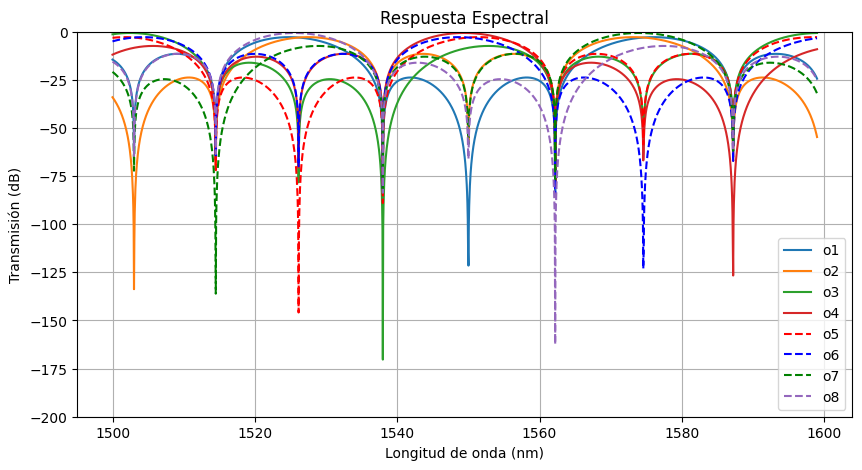

In [232]:
#n_eff = n_eff0+(n_eff0-n_g)*(wvl-wvl0)/wvl0
n_eff=n_eff0
beta=2*np.pi*n_eff/wvl
#D=np.exp(-1j*alpha*L)*np.exp(-1j*beta*L)
D=np.exp(-1j*beta*L)
D1=np.exp(-1j*beta*L/2)
D2=np.exp(-1j*beta*L/4)

PS1=np.exp(1j*0)
PS1_1=np.exp(1j*np.pi)

PS2=np.exp(1j*0)
PS3=np.exp(1j*(np.pi/4))
PS4=np.exp(1j*np.pi/2)
PS5=np.exp(1j*(3*np.pi/4))



Out1=1/8 * (D+1)*(D1*PS1-1)*(D2*PS2-1)
Out2=1/8 * (D+1)*(D1*PS1-1)*(1j*D2*PS2+1j)
Out3=1/8 * (D+1)*(1j*D1*PS1+1j)*(D2*PS3-1)
Out4=1/8 * (D+1)*(1j*D1*PS1+1j)*(1j*D2*PS3+1j)

Out5=1/8 * (D+1)*(D1*PS1_1-1)*(D2*PS4-1)
Out6=1/8 * (D+1)*(D1*PS1_1-1)*(1j*D2*PS4+1j)
Out7=1/8 * (D+1)*(1j*D1*PS1_1+1j)*(D2*PS5-1)
Out8=1/8 * (D+1)*(1j*D1*PS1_1+1j)*(1j*D2*PS5+1j)


plt.figure(figsize=(10, 5))
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out1)**2),label='o1')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out2)**2),label='o2')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out3)**2),label='o3')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out4)**2),label='o4')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out5)**2),linestyle='--',color='r',label='o5')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out6)**2),linestyle='--',color='b',label='o6')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out7)**2),linestyle='--',color='g',label='o7')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out8)**2),linestyle='--',label='o8')
plt.ylim(-200,0)
plt.legend()
plt.title("Respuesta Espectral")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Transmisión (dB)")
plt.grid(True)
plt.show()